In [15]:
!pip install kagglehub pandas matplotlib scikit-learn nltk gensim seaborn

In [36]:
import kagglehub
import pandas as pd
import numpy as np
import os
import re
import nltk
import matplotlib.pyplot as plt
from nltk.corpus import stopwords

In [37]:
path = kagglehub.dataset_download("amananandrai/ag-news-classification-dataset")

files = os.listdir(path)
print(files)

file_path = os.path.join(path, files[0])
df = pd.read_csv(file_path)

df.head()

Using Colab cache for faster access to the 'ag-news-classification-dataset' dataset.
['train.csv', 'test.csv']


,Class Index,Title,Description
0,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli..."
1,3,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...
2,3,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...
3,3,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...
4,3,"Oil prices soar to all-time record, posing new...","AFP - Tearaway world oil prices, toppling reco..."


In [45]:
import nltk
import re
from nltk.corpus import stopwords

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def preprocess(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return " ".join(words)

df['clean_text'] = df['text'].apply(preprocess)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


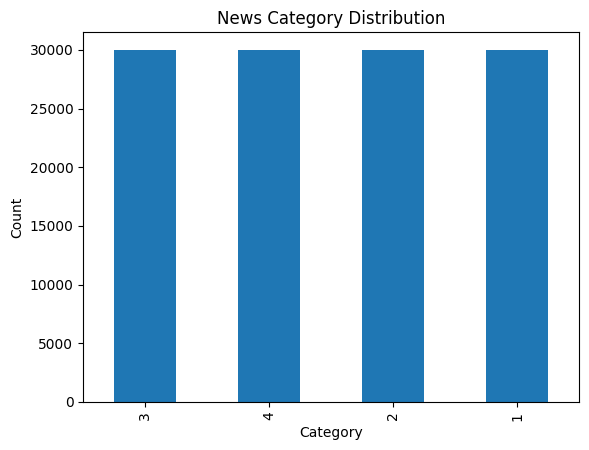

In [46]:
import matplotlib.pyplot as plt

df['label'].value_counts().plot(kind='bar')

plt.title("News Category Distribution")
plt.xlabel("Category")
plt.ylabel("Count")

plt.show()

In [47]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2)
)

X = vectorizer.fit_transform(df['clean_text'])
y = df['label']

In [48]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [49]:
from sklearn.svm import LinearSVC

model = LinearSVC()
model.fit(X_train, y_train)

LinearSVC()

In [50]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9162916666666666


In [52]:
def predict_news(text):
    text = preprocess(text)
    vec = vectorizer.transform([text])
    return model.predict(vec)[0]

print(predict_news("stock market crashes today"))
print(predict_news("new AI technology released"))

3
4


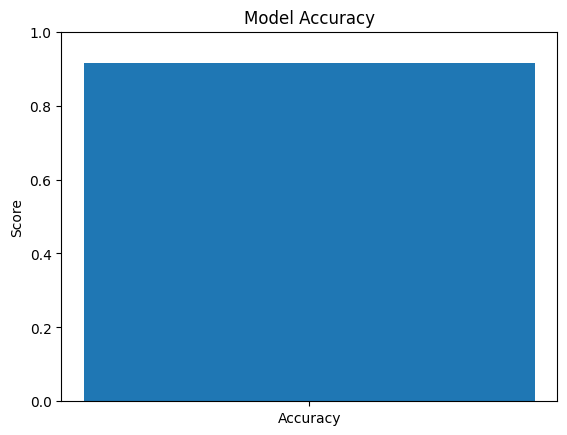

In [53]:
import matplotlib.pyplot as plt

plt.figure()
plt.bar(['Accuracy'], [accuracy])

plt.title("Model Accuracy")
plt.ylabel("Score")

plt.ylim(0,1)
plt.show()

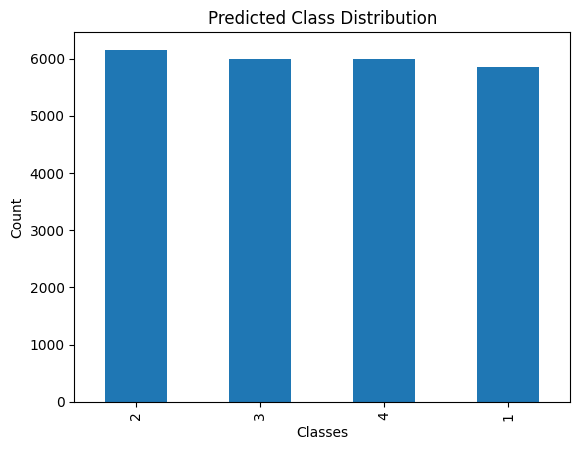

In [54]:
import pandas as pd

pred_df = pd.Series(y_pred)

plt.figure()
pred_df.value_counts().plot(kind='bar')

plt.title("Predicted Class Distribution")
plt.xlabel("Classes")
plt.ylabel("Count")

plt.show()

In [55]:
comparison = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
})

print(comparison.head(20))

    Actual  Predicted
0        3          3
1        2          2
2        3          2
3        3          4
4        1          2
5        4          2
6        3          4
7        4          4
8        3          3
9        2          2
10       2          2
11       4          4
12       3          3
13       4          1
14       3          3
15       4          4
16       3          3
17       1          1
18       2          2
19       4          4
